In [1]:
import os
import sys
import pandas as pd
import pyarrow.dataset as pads
import numpy as np
import matplotlib.pyplot as plt

BASE = 'Data'

def load_partitioned(table_type, filter_expr=None, columns=None):
    """Load a partitioned dataset into a pandas DataFrame."""
    ds = pads.dataset(
        source=os.path.join(BASE, table_type),
        format='csv',
        partitioning=['home_team', 'away_team', 'year', 'day']
    )
    return ds.to_table(filter=filter_expr, columns=columns).to_pandas()

print('Base path:', os.path.abspath(BASE))

Base path: /Users/andrewzaletski/Desktop/VSCode/SMT-Data-Challenge-2026/Data


In [2]:
# Cleaning helper functions

def clean_game_info(df):
    return df.drop_duplicates('game_string')

def clean_ball_events(df):
    df = df[df['game_string'] != 'NA'].copy()
    df = df[df['play_per_game'].notna()]
    df = df[df['play_per_game'] > 0]
    return df

def clean_ball_positions(df):
    df = df[df['game_string'] != 'NA'].copy()
    df = df[df['play_per_game'].notna()]
    df = df[(df['ball_position_z'] > -1) & (df['ball_position_z'] < 200)]
    return df

print('Cleaning functions defined.')

Cleaning functions defined.


In [3]:
game_info = pd.read_csv(os.path.join(BASE, 'game-info.csv'))
game_info_cleaned = clean_game_info(game_info)
print('Game info loaded and cleaned. Sample:')
print(game_info_cleaned.head())
print(len(game_info_cleaned), 'rows after cleaning game info.')

Game info loaded and cleaned. Sample:
       game_string year game_date  away_team_level away_team  home_team_level  \
0  y1_d061_VKA_PHD   y1      d061                7       VKA                7   
1  y1_d062_VKA_PHD   y1      d062                7       VKA                7   
2  y1_d063_VKA_PHD   y1      d063                7       VKA                7   
3  y1_d064_VKA_PHD   y1      d064                7       VKA                7   
4  y1_d065_VAS_PHD   y1      d065                7       VAS                7   

  home_team  
0       PHD  
1       PHD  
2       PHD  
3       PHD  
4       PHD  
250 rows after cleaning game info.


In [4]:
lineups = pd.read_csv(os.path.join(BASE, 'lineups.csv'))
print('Lineups loaded. Sample:')
print(lineups.head())
print(len(lineups), 'rows in lineups.')

Lineups loaded. Sample:
       game_string  inning half_inning home_team away_team  at_bat  \
0  y1_d061_VKA_PHD       1         Top       PHD       VKA       1   
1  y1_d061_VKA_PHD       1         Top       PHD       VKA       1   
2  y1_d061_VKA_PHD       1         Top       PHD       VKA       2   
3  y1_d061_VKA_PHD       1         Top       PHD       VKA       3   
4  y1_d061_VKA_PHD       1         Top       PHD       VKA       3   

   play_per_game  is_pickoff   pitcher   catcher  ... second_baseman  \
0              1       False  PHD-4341  PHD-5504  ...       PHD-7743   
1              2       False  PHD-4341  PHD-5504  ...       PHD-7743   
2              3       False  PHD-4341  PHD-5504  ...       PHD-7743   
3              4       False  PHD-4341  PHD-5504  ...       PHD-7743   
4              5       False  PHD-4341  PHD-5504  ...       PHD-7743   

  third_baseman shortstop left_fielder center_fielder right_fielder    batter  \
0      PHD-6069  PHD-0812     PHD-7166   

In [5]:
ball_events = load_partitioned('ball-events', filter_expr=pads.field('play_per_game') > 0)
ball_events_cleaned = clean_ball_events(ball_events)
print('Ball events loaded and cleaned. Sample:')
print(ball_events_cleaned.head())
print(len(ball_events_cleaned), 'rows after cleaning ball events.')

Ball events loaded and cleaned. Sample:
       game_string  play_per_game  timestamp  player_id  ball_eventcode  \
0  y1_d143_ADQ_ANI              1      50804          1               1   
1  y1_d143_ADQ_ANI              1      51254          2               2   
2  y1_d143_ADQ_ANI              1      51254          0               5   
3  y1_d143_ADQ_ANI              2      68204          1               1   
4  y1_d143_ADQ_ANI              2      68654          2               2   

  home_team away_team year   day  
0       ANI       ADQ   y1  d143  
1       ANI       ADQ   y1  d143  
2       ANI       ADQ   y1  d143  
3       ANI       ADQ   y1  d143  
4       ANI       ADQ   y1  d143  
283737 rows after cleaning ball events.


In [6]:
ball_positions = load_partitioned('ball-positions')
ball_positions_cleaned = clean_ball_positions(ball_positions)
print('Ball positions loaded and cleaned. Sample:')
print(ball_positions_cleaned.head())
print(len(ball_positions_cleaned), 'rows after cleaning ball positions.')

Ball positions loaded and cleaned. Sample:
       game_string  play_per_game  timestamp  ball_position_x  \
0  y1_d143_ADQ_ANI            1.0    50804.0        -1.800237   
1  y1_d143_ADQ_ANI            1.0    50854.0        -1.503474   
2  y1_d143_ADQ_ANI            1.0    50904.0        -1.229208   
3  y1_d143_ADQ_ANI            1.0    50954.0        -0.977445   
4  y1_d143_ADQ_ANI            1.0    51004.0        -0.748176   

   ball_position_y  ball_position_z home_team away_team year   day  
0         56.66940          6.24252       ANI       ADQ   y1  d143  
1         49.86540          6.12183       ANI       ADQ   y1  d143  
2         43.14060          5.93865       ANI       ADQ   y1  d143  
3         36.49560          5.69295       ANI       ADQ   y1  d143  
4         29.92956          5.38470       ANI       ADQ   y1  d143  
2239582 rows after cleaning ball positions.


In [7]:
player_positions = load_partitioned('player-positions')
print('Player positions loaded and cleaned. Sample:')
print(player_positions.head())
print(len(player_positions), 'rows in player positions.')

Player positions loaded and cleaned. Sample:
       game_string  play_per_game  timestamp  player_id  field_x   field_y  \
0  y1_d143_ADQ_ANI            1.0    50804.0          1  -1.0245   57.3042   
1  y1_d143_ADQ_ANI            1.0    50804.0          2  -0.0585   -4.5294   
2  y1_d143_ADQ_ANI            1.0    50804.0          3  73.5024   96.2754   
3  y1_d143_ADQ_ANI            1.0    50804.0          4  41.1609  148.5990   
4  y1_d143_ADQ_ANI            1.0    50804.0          5 -45.1584   79.9437   

  home_team away_team year   day  
0       ANI       ADQ   y1  d143  
1       ANI       ADQ   y1  d143  
2       ANI       ADQ   y1  d143  
3       ANI       ADQ   y1  d143  
4       ANI       ADQ   y1  d143  
65630708 rows in player positions.


---
## Establishing Potential Strike Zone

In [8]:
# Static zone and plate dimensions

plate_width_ft = 17/12
ball_radius_ft = 0.21
strike_zon_x_min = -plate_width_ft/2 - ball_radius_ft
strike_zon_x_max = plate_width_ft/2 + ball_radius_ft
strike_zon_bot = 1.5
strike_zon_top = 3.5
plate_front_y = 17/12



In [9]:
# Build pitch windows

releases = (
    ball_events_cleaned[ball_events_cleaned['ball_eventcode'] == 1]
    .groupby(['game_string', 'play_per_game'], as_index=False)['timestamp']
    .first()
    .rename(columns={'timestamp': 't_release'})
)

catches = (
    ball_events_cleaned[ball_events_cleaned['ball_eventcode'] == 2]
    .groupby(['game_string', 'play_per_game'], as_index=False)['timestamp']
    .first()
    .rename(columns={'timestamp': 't_catch'})
)

pitch_windows = releases.merge(catches, on=['game_string', 'play_per_game'])
print(f'Pitch windows built: {len(pitch_windows):,} pitches')

# Exclude pickoffs

lineup_plays = (
    lineups[['game_string', 'play_per_game', 'is_pickoff']]
    .drop_duplicates(subset=['game_string', 'play_per_game'])
)

pitch_windows = pitch_windows.merge(lineup_plays, on=['game_string', 'play_per_game'], how='left')
pitch_windows = pitch_windows[pitch_windows['is_pickoff'] != True].drop(columns='is_pickoff')
print(f'After removing pickoffs: {len(pitch_windows):,} pitches')

Pitch windows built: 59,342 pitches
After removing pickoffs: 59,342 pitches


In [10]:
# Slice ball-positions to pitch flight frames only

bp_with_window = ball_positions_cleaned.merge(
    pitch_windows, on=['game_string', 'play_per_game'], how='inner'
)

bp_flight = bp_with_window[
    (bp_with_window['timestamp'] >= bp_with_window['t_release']) &
    (bp_with_window['timestamp'] <= bp_with_window['t_catch'])
].copy()

print(f'In-flight frames: {len(bp_flight):,}')

In-flight frames: 1,628,901


In [11]:
# Interpolate X and Z at the front of the plate for each pitch

def interpolate_plate_crossing(group):
    g = group.sort_values('ball_position_y', ascending=False)
    above = g[g['ball_position_y'] >= plate_front_y]
    below = g[g['ball_position_y'] <  plate_front_y]

    if above.empty or below.empty:
        return pd.Series({'x_plate': np.nan, 'z_plate': np.nan})

    y1 = above.iloc[-1]['ball_position_y']
    x1 = above.iloc[-1]['ball_position_x']
    z1 = above.iloc[-1]['ball_position_z']

    y2 = below.iloc[0]['ball_position_y']
    x2 = below.iloc[0]['ball_position_x']
    z2 = below.iloc[0]['ball_position_z']

    t = (plate_front_y - y1) / (y2 - y1)
    return pd.Series({'x_plate': x1 + t * (x2 - x1),
                      'z_plate': z1 + t * (z2 - z1)})

plate_crossings = (
    bp_flight
    .groupby(['game_string', 'play_per_game'])
    .apply(interpolate_plate_crossing)
    .reset_index()
)

print(f'Plate crossings computed: {len(plate_crossings):,}')
print(f'Missing (ball never reached plate in tracking): {plate_crossings["x_plate"].isna().sum():,}')

# Apply zone bounds and bounce guard

pc = plate_crossings.dropna(subset=['x_plate', 'z_plate']).copy()

pc['bounced']   = pc['z_plate'] < 0.5
pc['in_zone_x'] = pc['x_plate'].between(strike_zon_x_min, strike_zon_x_max)
pc['in_zone_z'] = pc['z_plate'].between(strike_zon_bot, strike_zon_top)
pc['in_zone']   = pc['in_zone_x'] & pc['in_zone_z'] & ~pc['bounced']

print(pc[['in_zone_x', 'in_zone_z', 'in_zone', 'bounced']].mean().round(3))

Plate crossings computed: 59,341
Missing (ball never reached plate in tracking): 5,905
in_zone_x    0.651
in_zone_z    0.612
in_zone      0.400
bounced      0.049
dtype: float64


/var/folders/5p/vrbc0kc57yd4shnbpk0r_0rw0000gn/T/ipykernel_94286/1953171183.py:26: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(interpolate_plate_crossing)


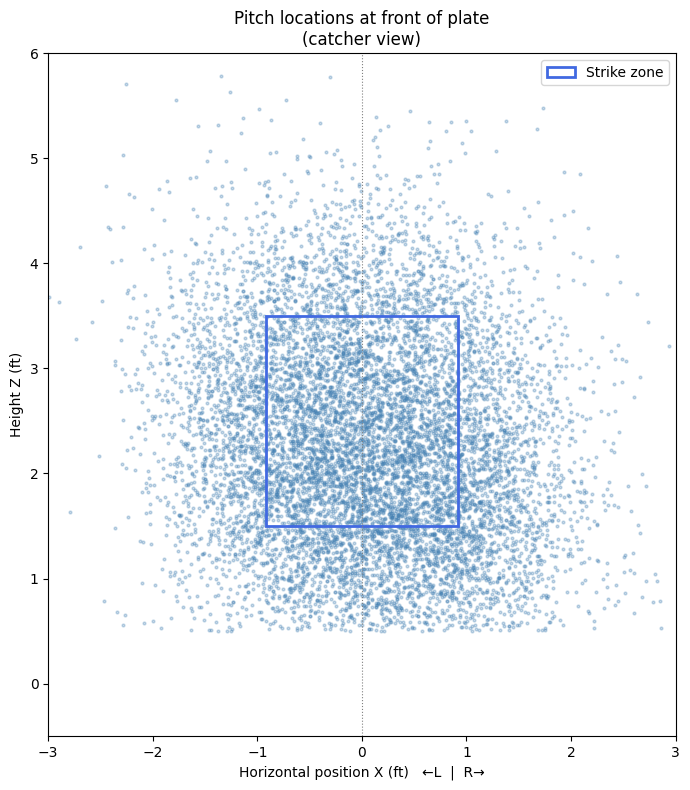

In [12]:
# Step 7: Sanity check

from matplotlib.patches import Rectangle

sample = pc[~pc['bounced']].sample(min(10_000, len(pc)), random_state=42)

fig, ax = plt.subplots(figsize=(7, 8))
ax.scatter(sample['x_plate'], sample['z_plate'], s=4, alpha=0.3, color='steelblue')

zone = Rectangle(
    (strike_zon_x_min, strike_zon_bot),
    strike_zon_x_max - strike_zon_x_min,
    strike_zon_top - strike_zon_bot,
    linewidth=2, edgecolor='royalblue', facecolor='none', label='Strike zone'
)
ax.add_patch(zone)

ax.set_xlim(-3, 3)
ax.set_ylim(-0.5, 6)
ax.set_xlabel('Horizontal position X (ft)   ←L  |  R→')
ax.set_ylabel('Height Z (ft)')
ax.set_title('Pitch locations at front of plate\n(catcher view)')
ax.axvline(0, color='gray', linestyle=':', linewidth=0.8)
ax.legend()
plt.tight_layout()
plt.show()